# Intelligents OQS

## Imports

In [1]:
import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier, OutputCodeClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE
import ucimlrepo
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from all_iqc import *

n_times_kfold = 1
k_times_fold = 10

## Base de Dados

### Real Datasets

#### Iris

In [6]:
#Gerando o dataset
iris = fetch_ucirepo(id=53)
# data (as pandas dataframes) 
X_data = iris.data.features 
X_data = X_data.values
y_data = iris.data.targets
y_data = y_data.values
str_DF = 'iris'

#Parâmetros
RANDOM_SEED = 1
LEARNING_RATE = 0.01
N_FEATURES = len(X_data[0])
N_SAMPLES = len(X_data)
N_PRINTINGS = N_SAMPLES//2
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,0.1)
QUBITS=[i for i in range(N_QUBITS)]
N_SHOTS=2048
N_ITER=200

#### Wine

In [2]:
# fetch dataset 
wine = fetch_ucirepo(id=109)
# data (as pandas dataframes) 
X_data = wine.data.features 
X_data = X_data.values
y_data = wine.data.targets
y_data = y_data.values
str_DF = 'wine'

#Parâmetros
RANDOM_SEED = 1
LEARNING_RATE = 0.01
N_FEATURES = len(X_data[0])
N_SAMPLES = len(X_data)
N_PRINTINGS = N_SAMPLES//2
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,0.1)
QUBITS=[i for i in range(N_QUBITS)]
N_SHOTS=2048
N_ITER=200

### Artificial Datasets

#### Blobs

In [2]:
#Parâmetros
RANDOM_SEED = 1
N_SAMPLES = 300
N_FEATURES = 4
N_CENTERS = 5
N_PRINTINGS = N_SAMPLES//2
N_SHOTS=2048
N_ITER=200
LEARNING_RATE = 0.01
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,1)
QUBITS=[i for i in range(N_QUBITS)]

#Gerando o dataset
def generate_blobs(n_samples, n_features, n_centers,normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_centers, random_state=RANDOM_SEED,cluster_std=0.7)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_data,y_data=generate_blobs(N_SAMPLES, N_FEATURES, N_CENTERS,normalize_col=False, normalize_lin=False)
str_DF = 'blobs'

#### Circles

In [2]:
#Parâmetros
RANDOM_SEED = 1
N_SAMPLES = 300
NOISE=0.05
N_FEATURES=2
N_PRINTINGS = N_SAMPLES//10
N_SHOTS=2048
LEARNING_RATE = 0.01
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,1)
QUBITS=[i for i in range(N_QUBITS)]
N_ITER=200

#Gerando o dataset
def generate_circles(n_samples, noise, factor, normalize_col=False, normalize_lin=False):
  X, y = make_circles(n_samples=n_samples, random_state=1, factor=factor, noise=noise)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_data,y_data=generate_circles(N_SAMPLES, 0.05, 0.5,normalize_lin=False)
str_DF = 'circles'

#### Moons

In [2]:
#Parâmetros
RANDOM_SEED = 1
N_SAMPLES = 300
NOISE=0.05
N_FEATURES=2
N_PRINTINGS = N_SAMPLES//10
N_SHOTS=2048
LEARNING_RATE = 0.01
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,1)
QUBITS=[i for i in range(N_QUBITS)]
N_ITER=200

#Gerando o dataset
def generate_moons(n_samples, noise, normalize_col=False, normalize_lin=False):
  X, y = make_moons(n_samples=n_samples, random_state=RANDOM_SEED, noise=noise)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_data,y_data=generate_moons(N_SAMPLES, 0.05,normalize_lin=False)
str_DF = 'moons'

## Tratamento do Dataset

In [ ]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        data = preprocessing.normalize(data,axis=0,norm='l2')
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normaliza a linha entre [-1,1]
    return data
    
X_data_iqc_ail_coluna=normalize_iqc_ail(X_data, normalize_col=True, normalize_lin=False)
X_data_iqc_ail_linha=normalize_iqc_ail(X_data,normalize_col=False,normalize_lin=True)

#### Boxplot IQC:AIL Column Normalized

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(X_data_iqc_ail_coluna, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_iris_iqc_ail_coluna.svg')

#### Boxplot IQC:AIL Line Normalized

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(X_data_iqc_ail_linha, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_iris_iqc_ail_linha.svg')

## Treinamento

#### IQC AIL LINHA


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


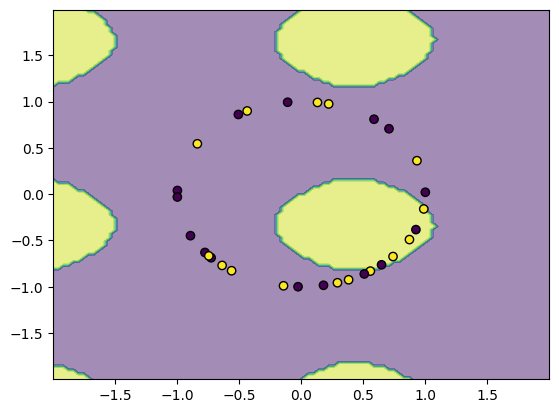

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


KeyboardInterrupt: 

In [ ]:
'''
for SEED in range(n_times_kfold):
    scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                    X, 
                    y, 
                    k_folds=k_times_fold,
                    random_seed = SEED, 
                    classifier_function=classifier_function, 
                    dic_classifier_params=dic_classifier_params,
                    one_vs_classifier=OneVsRestClassifier, 
                    dic_training_params=dic_training_params,
                    print_each_fold_metric=True,
                    print_avg_metric=False)
    scores_list.append(scores)
    f1scores_list.append(f1scores)
    negativities_list.append(output_dict["negativities"])
'''
modelo = 'IQC_AIL_Linha'
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 1
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES)


dic_training_params = {"max_iter": 200,
    "accuracy_succ": 0.99,
    "plot_graphs_and_metrics": False,
    "plot_graphs_in_classifier": False,
    "random_seed": 1,
    "learning_rate": 0.01,
    "refit_db":True,
    "reset_weights_epoch":0,
    "do_classes_refit":True,
    "batch":False}
    
scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False,
                        plot_boundary_decision_original=True)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)

#### IQC AIL COLUNA

In [6]:
modelo = 'IQC_AIL_Coluna'
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES)


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   22.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 2


...


 SEED = 28


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 29


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   22.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   22.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   22.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


Weights saved in: IQC_AIL_Coluna_wine_weights_2025-09-11_13-41-58.csv
Negativity_Class_0 - AVG: 0.3247 ± 0.0000
Negativity_Class_1 - AVG: 0.3273 ± 0.0000
Negativity_Class_2 - AVG: 0.3304 ± 0.0000

Negativity saved in: IQC_AIL_Coluna_wine_negativity_2025-09-11_13-41-58.csv

Metrics for 30 times 10 folds:
Best Accuracy: 0.9611
Best F1-Score: 0.9625
AVG Accuracy: 0.9492 ± 0.0016
AVG F1-Score: 0.9505 ± 0.0015

Metrics saved in: IQC_AIL_Coluna_wine_metrics_results_2025-09-11_13-41-58.csv


#### IQC LINHA

In [7]:
modelo = 'IQC_Linha'
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES)


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   26.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 2


...


 SEED = 28


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 29


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   27.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   26.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


Weights saved in: IQC_Linha_wine_weights_2025-09-11_15-44-50.csv
Negativity_Class_0 - AVG: 0.2204 ± 0.0000
Negativity_Class_1 - AVG: 0.1885 ± 0.0001
Negativity_Class_2 - AVG: 0.1978 ± 0.0005

Negativity saved in: IQC_Linha_wine_negativity_2025-09-11_15-44-50.csv

Metrics for 30 times 10 folds:
Best Accuracy: 0.5444
Best F1-Score: 0.4696
AVG Accuracy: 0.5085 ± 0.0037
AVG F1-Score: 0.4271 ± 0.0044

Metrics saved in: IQC_Linha_wine_metrics_results_2025-09-11_15-44-50.csv


#### IQC COLUNA

In [8]:
modelo = 'IQC_Coluna'
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES)


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   22.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   22.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 2


...


 SEED = 28


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   22.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   26.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   26.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 29


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   24.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


Weights saved in: IQC_Coluna_wine_weights_2025-09-11_17-47-52.csv
Negativity_Class_0 - AVG: 0.3247 ± 0.0000
Negativity_Class_1 - AVG: 0.3273 ± 0.0000
Negativity_Class_2 - AVG: 0.3304 ± 0.0000

Negativity saved in: IQC_Coluna_wine_negativity_2025-09-11_17-47-52.csv

Metrics for 30 times 10 folds:
Best Accuracy: 0.9611
Best F1-Score: 0.9625
AVG Accuracy: 0.9492 ± 0.0016
AVG F1-Score: 0.9505 ± 0.0015

Metrics saved in: IQC_Coluna_wine_metrics_results_2025-09-11_17-47-52.csv


#### IQC_PQ, N_qubits_tgt = 2, dic_classifier_params["normalize_axis"] = 1

In [3]:
modelo = 'IQCpQ_tgt2_Linha'
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
N_qubits_tgt = 2
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES, N_qubits_tgt)

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 2


...


 SEED = 28


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 29


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


Weights saved in: IQCpQ_tgt2_Linha_wine_weights_2025-09-22_09-46-04.csv
Negativity_Class_0 - AVG: 0.2267 ± 0.0000
Negativity_Class_1 - AVG: 0.2239 ± 0.0000
Negativity_Class_2 - AVG: 0.2272 ± 0.0000

Negativity saved in: IQCpQ_tgt2_Linha_wine_negativity_2025-09-22_09-46-04.csv

Metrics for 30 times 10 folds:
Best Accuracy: 0.2693
Best F1-Score: 0.1413
AVG Accuracy: 0.2693 ± 0.0000
AVG F1-Score: 0.1413 ± 0.0000

Metrics saved in: IQCpQ_tgt2_Linha_wine_metrics_results_2025-09-22_09-46-04.csv


#### IQC_PQ, N_qubits_tgt = 2, dic_classifier_params["normalize_axis"] = 0

In [3]:
modelo = 'IQCpQ_tgt2_Coluna'
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
N_qubits_tgt = 2
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES, N_qubits_tgt)

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   52.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   56.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   53.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   52.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   56.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   59.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out


 SEED = 1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   59.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   58.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   57.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out


 SEED = 2


...


 SEED = 28


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   59.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   56.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   58.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   56.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out


 SEED = 29


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   57.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   56.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   58.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out


Weights saved in: IQCpQ_tgt2_Coluna_blobs_weights_2025-09-24_01-02-44.csv
Negativity_Class_0 - AVG: 0.6162 ± 0.0002
Negativity_Class_1 - AVG: 0.5277 ± 0.0001
Negativity_Class_2 - AVG: 0.4790 ± 0.0000
Negativity_Class_3 - AVG: 0.6077 ± 0.0002
Negativity_Class_4 - AVG: 0.6250 ± 0.0008

Negativity saved in: IQCpQ_tgt2_Coluna_blobs_negativity_2025-09-24_01-02-44.csv

Metrics for 30 times 10 folds:
Best Accuracy: 0.4567
Best F1-Score: 0.3748
AVG Accuracy: 0.4141 ± 0.0040
AVG F1-Score: 0.3395 ± 0.0035

Metrics saved in: IQCpQ_tgt2_Coluna_blobs_metrics_results_2025-09-24_01-02-44.csv


#### IQC_PQ, N_qubits_tgt = 4, dic_classifier_params["normalize_axis"] = 1

In [5]:
modelo = 'IQCpQ_tgt4_Linha'
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
N_qubits_tgt = 4
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES, N_qubits_tgt)

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


KeyboardInterrupt: 

#### IQC_PQ, N_qubits_tgt = 4, dic_classifier_params["normalize_axis"] = 0

In [6]:
modelo = 'IQCpQ_tgt4_Coluna'
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
N_qubits_tgt = 4
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES, N_qubits_tgt)

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


KeyboardInterrupt: 

#### IQCNDsE, dic_classifier_params["normalize_axis"] = 1


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


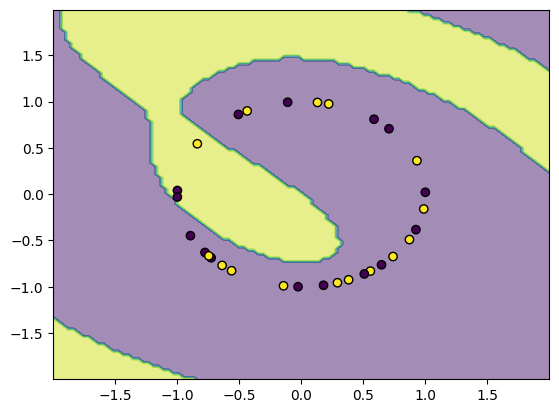

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


KeyboardInterrupt: 

In [4]:
modelo = 'IQCNDsE_Linha'
classifier_function = iqcndsE_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES)

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=True)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=True)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)

#### IQCNDsE, dic_classifier_params["normalize_axis"] = 0

In [6]:
modelo = 'IQCNDsE_Coluna'
classifier_function = iqcndsE_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES)

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=False)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=True)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)


 SEED = 0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   33.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 2


...


 SEED = 28


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   34.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


 SEED = 29


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   31.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out


Weights saved in: IQCNDsE_Coluna_wine_weights_2025-09-12_15-45-56.csv
Negativity_Class_0 - AVG: 0.3165 ± 0.0001
Negativity_Class_1 - AVG: 0.3030 ± 0.0000
Negativity_Class_2 - AVG: 0.3286 ± 0.0002

Negativity saved in: IQCNDsE_Coluna_wine_negativity_2025-09-12_15-45-56.csv

Metrics for 30 times 10 folds:
Best Accuracy: 0.9719
Best F1-Score: 0.9731
AVG Accuracy: 0.9580 ± 0.0017
AVG F1-Score: 0.9592 ± 0.0017

Metrics saved in: IQCNDsE_Coluna_wine_metrics_results_2025-09-12_15-45-56.csv


#### IQC_ANGLE LINHA


 SEED = 0


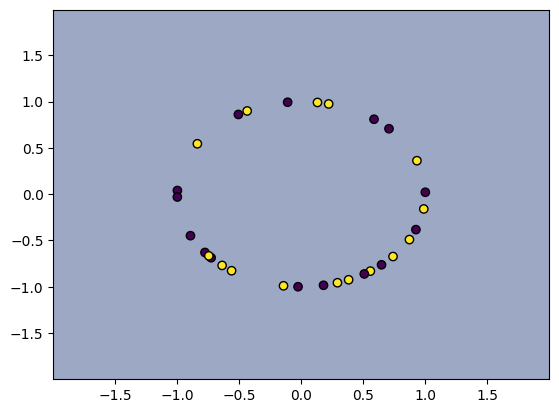

KeyboardInterrupt: 

In [ ]:
modelo = 'IQC_Angle_Linha'
classifier_function = iqc_angle_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1
dic_classifier_params["N_layers"] = 2
dic_classifier_params["iqc_angle"] = True
dic_classifier_params["qubits"] = [i for i in range(math.ceil(np.log2(N_FEATURES)+1))]

"""if str_DF=='wine':
    if len(X_data[0]) != N_FEATURES:
        raise ValueError("N_FEATURES is different from the dataset features")"""

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES)
    
dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False
}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=True)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=True)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)

#### IQC_ANGLE COLUNA

In [ ]:
modelo = 'IQC_Angle_Coluna'
classifier_function = iqc_angle_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1
dic_classifier_params["N_layers"] = 2
dic_classifier_params["iqc_angle"] = True
dic_classifier_params["qubits"] = [i for i in range(math.ceil(np.log2(N_FEATURES)+1))]

"""if str_DF=='wine':
    if len(X_data[0]) != N_FEATURES:
        raise ValueError("N_FEATURES is different from the dataset features")"""

if str_DF=='wine':
    X_data=modify_dataset(X_data, dic_classifier_params["N_qubits"], N_SAMPLES)
    
dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False
}

scores_list = []
f1scores_list = []
weights_list = []

if str_DF!='circles' and str_DF!='moons':
    negativities_list = []
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, output_dict, weights = execute_training_test_k_fold(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=True)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        negativities_list.append(np.mean(output_dict["negativities"],axis=1))# = np.copy(output_dict["negativities"])
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_negativity(np.array(negativities_list).T, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)
else:
    for SEED in range(n_times_kfold):
        print('\n', f'SEED = {SEED}')
        scores, f1scores, ashj, weights = execute_training_test_k_fold_two_classes(
                        X_data, 
                        y_data, 
                        k_folds=k_times_fold,
                        random_seed = SEED, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=False,
                        print_avg_metric=True)
        scores_list.append(np.mean(scores))
        f1scores_list.append(np.mean(f1scores))
        weights_list.append(np.array(weights))
    print_and_save_weights(weights_list, modelo, str_DF)
    print_and_save_metrics(scores_list, f1scores_list, n_times_kfold, k_times_fold, modelo, str_DF, print_all=False)

#### Models Runs

##### IRIS
- IQC_AIL Linha: 1
- IQC_AIL Coluna: 1
- IQC Linha: 1
- IQC Coluna: 1
- IQCpQ_tgt2 Linha: 1
- IQCpQ_tgt2 Coluna: 1
- IQCNDsE Linha: 1
- IQCNDsE Coluna: 1
- IQC_Angle Linha: 1
- IQC_Angle Coluna: 1
##### BLOBS
- IQC_AIL Linha: 1
- IQC_AIL Coluna: 1
- IQC Linha: 1
- IQC Coluna: 1
- IQCpQ_tgt2 Linha: 1
- IQCpQ_tgt2 Coluna: 1
- IQCNDsE Linha: 1
- IQCNDsE Coluna: 1
- IQC_Angle Linha: 1, 300*2.8
- IQC_Angle Coluna: 1
##### CIRCLES
- IQC_AIL Linha: 1
- IQC_AIL Coluna: 1
- IQC Linha: 1
- IQC Coluna: 1
- IQCpQ_tgt2 Linha: 1
- IQCpQ_tgt2 Coluna: 1
- IQCNDsE Linha: 1
- IQCNDsE Coluna: 1
- IQC_Angle Linha: 1
- IQC_Angle Coluna: 1
##### MOONS
- IQC_AIL Linha: 1
- IQC_AIL Coluna: 1
- IQC Linha: 1
- IQC Coluna: 1
- IQCpQ_tgt2 Linha: 1
- IQCpQ_tgt2 Coluna: 1
- IQCNDsE Linha: 1
- IQCNDsE Coluna: 1
- IQC_Angle Linha: 1
- IQC_Angle Coluna: 1
##### WINE
- IQC_AIL Linha: 1
- IQC_AIL Coluna: 1
- IQC Linha: 1
- IQC Coluna: 1
- IQCpQ_tgt2 Linha: 1
- IQCpQ_tgt2 Coluna: 1
- IQCNDsE Linha: 1
- IQCNDsE Coluna: 1
- IQC_Angle Linha: 1, 300*3min
- IQC_Angle Coluna: 1

#### Postponed for now

##### IRIS
- IQCpQ_tgt4 Linha: 1
- IQCpQ_tgt4 Coluna: 1
##### BLOBS
- IQCpQ_tgt4 Linha: 0, 300*5min
- IQCpQ_tgt4 Coluna: 0, 300*5min
##### CIRCLES
- IQCpQ_tgt4 Linha: 1
- IQCpQ_tgt4 Coluna: 1
##### MOONS
- IQCpQ_tgt4 Linha: 1
- IQCpQ_tgt4 Coluna: 1
##### WINE
- IQCpQ_tgt4 Linha: 0, 300*Xmin
- IQCpQ_tgt4 Coluna: 0, 300*(+65min)

#### Rascunho

In [12]:
import pandas as pd
import numpy as np

# Nome do arquivo
arquivo = 'IQC_AIL_Coluna_iris_negativity_2025-08-26_15-13-58.csv'

# Ler o arquivo
df = pd.read_csv(arquivo)

print(f"Formato original: {df.shape[0]} linhas x {df.shape[1]} colunas")
print("Primeiras linhas do arquivo original:")
print(df.head())

# Transpor os dados (transformar colunas em linhas e vice-versa)
df_transposto = df.T  # Transpor

# Resetar o índice e renomear colunas
df_transposto = df_transposto.reset_index()
df_transposto.columns = ['Class'] + [f'Execution_{i+1}' for i in range(df_transposto.shape[1] - 1)]

# Remover a primeira linha (cabeçalho antigo)
df_corrigido = df_transposto.iloc[1:].copy()

print(f"\nFormato corrigido: {df_corrigido.shape[0]} linhas x {df_corrigido.shape[1]} colunas")
print("Primeiras linhas do arquivo corrigido:")
print(df_corrigido.head())

# Salvar o arquivo corrigido
nome_corrigido = arquivo.replace('.csv', '_corrigido.csv')
df_corrigido.to_csv(nome_corrigido, index=False)

print(f"\nArquivo corrigido salvo como: {nome_corrigido}")

Formato original: 3 linhas x 30 colunas
Primeiras linhas do arquivo original:
   Negativity_Class_0  Negativity_Class_1  Negativity_Class_2  \
0            0.300622            0.300727            0.301237   
1            0.192153            0.191857            0.191403   
2            0.194214            0.191216            0.192659   

   Negativity_Class_3  Negativity_Class_4  Negativity_Class_5  \
0            0.300803            0.301664            0.302222   
1            0.192423            0.191683            0.191340   
2            0.189395            0.191235            0.191758   

   Negativity_Class_6  Negativity_Class_7  Negativity_Class_8  \
0            0.300764            0.301317            0.301417   
1            0.191630            0.192467            0.191367   
2            0.192017            0.191800            0.191607   

   Negativity_Class_9  ...  Negativity_Class_20  Negativity_Class_21  \
0            0.301919  ...             0.301464             0.30177

In [13]:
import pandas as pd

# Nome do arquivo
arquivo = 'IQC_AIL_Coluna_iris_negativity_2025-08-26_15-13-58_corrigido.csv'  # Substitua pelo nome real do seu arquivo

# Ler o arquivo
df = pd.read_csv(arquivo)

print("Formato original:")
print(df.head())
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

# Remover a primeira coluna categórica
df_sem_classe = df.drop(columns=['Class'])

# Renomear as colunas numéricas para Negativity_Class_i
novos_nomes = [f'Negativity_Class_{i}' for i in range(df_sem_classe.shape[1])]
df_sem_classe.columns = novos_nomes

print("\nFormato corrigido:")
print(df_sem_classe.head())
print(f"Dimensões: {df_sem_classe.shape[0]} linhas x {df_sem_classe.shape[1]} colunas")

# Salvar o arquivo corrigido
nome_corrigido = arquivo.replace('.csv', '_corrigido.csv')
df_sem_classe.to_csv(nome_corrigido, index=False)

print(f"\nArquivo corrigido salvo como: {nome_corrigido}")

Formato original:
                Class  Execution_1  Execution_2  Execution_3
0  Negativity_Class_1     0.300727     0.191857     0.191216
1  Negativity_Class_2     0.301237     0.191403     0.192659
2  Negativity_Class_3     0.300803     0.192423     0.189395
3  Negativity_Class_4     0.301664     0.191683     0.191235
4  Negativity_Class_5     0.302222     0.191340     0.191758
Dimensões: 29 linhas x 4 colunas

Formato corrigido:
   Negativity_Class_0  Negativity_Class_1  Negativity_Class_2
0            0.300727            0.191857            0.191216
1            0.301237            0.191403            0.192659
2            0.300803            0.192423            0.189395
3            0.301664            0.191683            0.191235
4            0.302222            0.191340            0.191758
Dimensões: 29 linhas x 3 colunas

Arquivo corrigido salvo como: IQC_AIL_Coluna_iris_negativity_2025-08-26_15-13-58_corrigido_corrigido.csv


In [ ]:
from qiskit.quantum_info import Operator, partial_trace
from qiskit import QuantumCircuit

def build_circuit_matrix(x_vals, N_layers=2):
    """
    Constrói numericamente a matriz do circuito com R_x (em todos os qubits exceto o primeiro)
    e CNOTs em cascata.
    
    Args:
        x_vals (list or np.array): lista de parâmetros [x_0, x_1, ..., x_{N_features}]
    
    Returns:
        np.array: matriz unitaría do circuito como um np.array complexo (2^N x 2^N)
    """
    N_features = len(x_vals)
    N_qubits = N_features + 1  # inclui o qubit extra (tipicamente ancilla ou controle)

    qc = QuantumCircuit(N_qubits)

    qc.h(0)  # Aplicar Hadamard no qubit 0
    for _ in range(N_layers):
        # Aplicar R_x(x_i) para qubits de 1 até N_features
        for i in range(1, N_qubits):
            qc.rx(x_vals[i-1], i)

        # Aplicar CNOTs em cascata: q1→q2, q2→q3, q3→q4, ..., até o penúltimo
        for i in range(1, N_qubits - 1):
            qc.cx(i, i + 1)
        
        qc.barrier()
        # Converter o circuito em matriz unitára
    display(qc.draw('mpl'))  # Desenhar o circuito para visualização (opcional)
    U = Operator(qc).data
    return U

NF=5
N_qubits=NF+1  # Número de qubits do circuito
qubits=[i for i in range(N_qubits)]

x = np.random.rand(NF)  # Exemplo de vetor de parâmetros
w = np.random.rand(2**(NF))  # Exemplo de vetor de pesos
M=build_angle_matrix(np.pi*x, N_qubits, N_layers=2)

sigmaX = np.array([[0,1], [1,0]])
sigmaY = np.array([[0,-1j], [1j,0]])
sigmaZ = np.array([[1,0], [0,-1]])
sigmaQ = sigmaX + sigmaY + sigmaZ

# Verifica se precisa ajustar sigmaE
sigmaE = np.diag(w)
"""# Calcula o operador unitário U
dim_circuit = 2 ** (N_qubits - 1)
dim_sigmaE = sigmaE.shape[0]
sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)"""

psi = Statevector.from_int(0, dims=2**N_qubits)
rho = DensityMatrix(psi.evolve(M))  # Evolução do estado inicial com a matriz M
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

rho_final = rho.evolve(U)  # Equivalente a U ρ U^†
rho_res = partial_trace(rho_final, qubits[1:])
display("Rho:", rho_res.draw('text'))
print("Pureza(rho_res):", (rho_res.purity()))
#rho_res.draw('city')


In [ ]:
def iqc_angle_classifier(vector_x, 
                   vector_ws,
                   normalize_x=False, 
                   normalize_w=False, 
                   dic_classifier_params={},
                   N_qubits=None,
                   N_qubits_tgt=None,
                   N_layers=None):
    # IQC-Angle Embedding
    """
        Applies the a modified version of ICQ classifier using only the math behind the Quantum Classifier described in Interactive Quantum Classifier Inspired by Quantum Open System Theory article. 
        
        It differs from the original ICQ by adding a new component to Sigma Q: sigmaH, which corresponds to a Haddamard's gate. Another difference is that we load the input in the environment instead of having a combination of weights and inputs in sigmaE.

        After doing so, it gets the result of Equation #20 and returns Z as the predicted class and the probability of being the class 1.
        
        Works only for binary classifications, therefore, if the probability of class 0 is needed, it can be 1 - probability of being class 1.

        There are a few possible keys for the dic_classifier_params:
        - sigma_q_params (array) = weights used for calculating sigma_q
        - use_polar_coordinates_on_sigma_q (boolean) = whether to calculate sigma_q using polar coordinates or weighted sum
        - load_inputvector_env_state (boolean) = whether to load input vector on the environment state (True) or on sigma_e (False)
        - operation_for_sigma_e (string) = which operation will be used to combine weights and X for load_inputvector_env_state = False. For now, only "sum" and "mul" are available.
        - calculate_negativity (boolean) = enables the negativity calculation. Check https://en.wikipedia.org/wiki/Negativity_(quantum_mechanics). Uses Toqito implementation: https://toqito.readthedocs.io/en/latest/_autosummary/toqito.state_props.negativity.html
        - ending_hadamard_gate (int) =  adds a Hadamard gate after the U operator
        - use_exponential_on_input (boolean) = does the Euler exponential on the input data after normalizing (if applied)

        To have the original ICQ Classifier, you can have:
        normalize_x = False
        normalize_w = False
        dic_classifier_params["load_inputvector_env_state"] = False
        dic_classifier_params["sigma_q_params"] = [1, 1, 1, 0]

        returns (z, p_cog_new_11_2, output_dict)

        output_dict contains:
        - U_operators = list of used U_operators
        - negativity = negativity associated with that entry
        - entropy = entropy associated with that entry
    """
    
    N = len(vector_x)
    if "sigma_q_params" in dic_classifier_params:
        sigma_q_params = dic_classifier_params["sigma_q_params"]
    if "use_polar_coordinates_on_sigma_q" in dic_classifier_params:
        use_polar_coordinates_on_sigma_q = dic_classifier_params["use_polar_coordinates_on_sigma_q"]
    

    if normalize_x:
        vector_x = normalize(vector_x)
    if "use_exponential_on_input" in dic_classifier_params and dic_classifier_params["use_exponential_on_input"]:
        vector_x = np.exp(vector_x)
    
    if (use_polar_coordinates_on_sigma_q):
        # Eq #16, but using polar coordinates so |sigmaQ| gets to be 1
        sigmaQ = get_sigmaQ_from_polar_coord(sigma_q_params)
    else:
        # Eq #16
        sigmaQ = get_weighted_sigmaQ(sigma_q_params)

    # We want to have multiple environments, thus we need to have a list of weights for each of them
    if not(isinstance(vector_ws, (list, np.ndarray)) and all(isinstance(item, (list, np.ndarray)) for item in vector_ws)):
        vector_ws = np.array(vector_ws, dtype=complex)
    
    '''
    # Eq 25
    p_env = np.ones((N,1))/np.sqrt(N)
    p_env = get_p(p_env)

    # Our first p_cog will be the original one, but will change overtime
    p_cog = np.ones((2,1)) / np.sqrt(2) 
    # Eq #18
    p_cog = get_p(p_cog)

    # We'll update the p_cog for every env we have
    p_cog_new = p_cog
    '''
    N_qubits = dic_classifier_params["N_qubits"]
    N_qubits_tgt = dic_classifier_params["N_qubits_tgt"]
    qubits = dic_classifier_params["qubits"]
    N_layers= dic_classifier_params["N_layers"]
    
    U_operators = []
    for vector_w in vector_ws:
        if normalize_w:
            vector_w = normalize(vector_w)
        # We don't want to mix both proposed approach and multiple environments, as it'll be confusing
        if len(vector_ws) > 1:
            raise Exception("Not possible to load weights on env and have multiple envs!")

        sigmaE = np.diag(vector_w)
        U_operator = get_U_operator(sigmaQ, sigmaE)
        U_operators.append(U_operator)

        print("Shape of sigmaQ:", sigmaQ.shape)
        print("Shape of sigmaE:", sigmaE.shape)
        print("Shape of U:", U_operator.shape)

        # Eq #19 applied on a Quantum state equivalent of Hadamard(|00...0>) = 1/sqrt(N) * (|00...0> + ... + |11...1>)
        # We can either have Hadamard applied to each instance attribute...
        vector_x_normalized = vector_x / (np.linalg.norm(vector_x) + 1e-16) 
        psi = Statevector.from_int(0, dims=2**N_qubits)
        M = build_angle_matrix(np.pi*vector_x_normalized, N_qubits, N_layers=N_layers)
        print("Shape of M:", M.shape)
        psi = psi.evolve(M)  # Equivalent to M * psi
        p = DensityMatrix(psi.evolve(M))  # Density matrix of the state after evolution M
        print("Shape of p:", p.data.shape)
        p_out = p.evolve(U_operator)  # Equivalente a U ρ U^†
        p_cog_new = partial_trace(p_out, qubits[1:]).data
    # As the result is a diagonal matrix, the probability of being class 0 will be on position 0,0
    p_cog_new_00_2 = p_cog_new[0,0]

    # ... and the probability of being class 1 will be on position 1,1
    p_cog_new_11_2 = p_cog_new[1,1]
    if (p_cog_new_00_2 >= p_cog_new_11_2):
        z = 0
    else:
        z = 1

    output_dict = {}
    output_dict["U_operators"] = U_operators
    
    if "calculate_negativity" in dic_classifier_params and dic_classifier_params["calculate_negativity"]:
        output_dict["negativity"] = get_negativity(p_out, [2, N])

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/evolution_calc.txt', 'a') as file:
        #     string_to_write = "\nvector_x = " + generate_output_matrix_string(vector_x) + ";\n"\
        #                     + "vector_w = " + generate_output_matrix_string(vector_w) + ";\n"\
        #                     + "p_cog_new = " + generate_output_matrix_string(p_cog_new) + ";\n"
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/ins_and_outs.txt', 'a') as file:
        #     string_to_write = "\nvector_x = " + generate_output_matrix_string(vector_x) + ";\n"\
        #                     + "vector_w = " + generate_output_matrix_string(vector_w) + ";\n"\
        #                     + "sigmaQ = " + generate_output_matrix_string(sigmaQ) + ";\n"\
        #                     + "sigmaE = " + generate_output_matrix_string(sigmaE) + ";\n"\
        #                     + "p_cog = " + generate_output_matrix_string(p_cog) + ";\n"\
        #                     + "p_env = " + generate_output_matrix_string(p_env) + ";\n"\
        #                     + "p_cog_env = " + generate_output_matrix_string(p_cog_env) + ";\n"\
        #                     + "p_out = " + generate_output_matrix_string(p_out) + ";\n"\
        #                     + "p_cog_new = " + generate_output_matrix_string(p_cog_new) + ";\n"
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/negativity.txt', 'a') as file:
        #     string_to_write = "\np_out = " + generate_output_matrix_string(p_out) + ";\n\n - Negativity = " + str(output_dict["negativity"])
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

    if "calculate_entropy" in dic_classifier_params and dic_classifier_params["calculate_entropy"]:
        output_dict["entropy"] = get_entropy(p_out)
        
        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/entropy.txt', 'a') as file:
        #     string_to_write = "\np_out = " + generate_output_matrix_string(p_out) + ";\n\n -Entropy = " + str(output_dict["entropy"])
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")
     
    return z, p_cog_new_11_2, output_dict

In [ ]:
NF=10
x = np.random.rand(NF)  # Exemplo de vetor de parâmetros
NQ = math.ceil(np.log2(NF)+1)
w = np.random.rand(2**(NQ-1))  # Exemplo de vetor de pesos

def build_angle_matrix(x_vals, N_qubits, N_layers=2):
    """
    Numerically constructs the circuit matrix with R_x gates (on all qubits except the first)
    and cascaded CNOTs. This function builds an unitary matrix that acts on Hilberts composed 
    state space.
    
    Args:
        x_vals (list or np.array): List of parameters [x_0, x_1, ..., x_{N_features}]
    
    Returns:
        np.array: Unitary matrix of the circuit as a complex np.array (2^N x 2^N)
    """
    
    qc = QuantumCircuit(N_qubits)

    qc.h(0)  # Apply Hadamard at q 0
    for _ in range(N_layers):
        # Apply R_x(x_i) for qubits from 1 to N_features
        for i in range(1, N_qubits):
            qc.rx(x_vals[i-1], i)

        # Apply cascaded CNOTs: q1→q2, q2→q3, q3→q4, ..., till qN-1→qN
        for i in range(1, N_qubits - 1):
            qc.cx(i, i + 1)
        
        # Convert circuit to unitary matrix
    M = Operator(qc).data
    return M

dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = NQ #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1
dic_classifier_params["N_layers"] = 2

dic_classifier_params["qubits"] = [i for i in range(NQ)]

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False,
"iqc_angle":True}

iqc_angle_classifier(x, 
                   [w],
                   normalize_x=False, 
                   normalize_w=False, 
                   dic_classifier_params=dic_classifier_params,
                   N_qubits=NQ,
                   N_qubits_tgt=1,
                   N_layers=2)

In [ ]:
from sympy import symbols, Matrix, eye, zeros
from numpy import kron
from sympy.physics.quantum import TensorProduct
from sympy import pprint

# Definir operadores básicos
I = eye(2)  # Identidade
X = Matrix([[0, 1], [1, 0]])  # Pauli-X
P0 = Matrix([[1, 0], [0, 0]])  # |0⟩⟨0|
P1 = Matrix([[0, 0], [0, 1]])   # |1⟩⟨1|

# Construir a matriz CNOT controlada por |0⟩ (qubit 2 → qubit 5)
termo_0 = TensorProduct(P0, I, I, I, X)  # Se qubit 2 = |0⟩, aplica X no qubit 5
termo_1 = TensorProduct(P1, I, I, I, I)  # Se qubit 2 = |1⟩, aplica I no qubit 5
CNOT_simbolica = termo_0 + termo_1

# Mostrar a matriz
print("Matriz CNOT controlada por |0⟩ (qubit 2 → qubit 5):")
pprint(CNOT_simbolica)